In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv("../data/processed/customers_mart.csv")
customers.head()

,customer_unique_id,total_orders,total_items,total_spent,avg_order_value,positive_reviews,negative_reviews,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,141.90,141.90,True,False,116
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,27.19,27.19,True,False,119
2,0000f46a3911fa3c0805444483337064,1,1,86.22,86.22,False,False,542
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,43.62,43.62,True,False,326
4,0004aac84e0df4da2b147fca70cf8255,1,1,196.89,196.89,True,False,293


### RFM-анализ
Разделим всех клиентов платформы на сегменты на основе их покупательского поведения:
* **Recency:** Сколько дней прошло с последней покупки. Чем меньше дней, тем лучше (оценка 5).
* **Frequency:** Сколько заказов сделал клиент. Чем больше, тем лучше.
* **Monetary:** Сколько денег клиент принес маркетплейсу. Чем больше, тем лучше.

In [8]:
customers['R_Score'] = pd.qcut(customers['recency'], q=5, labels=[5, 4, 3, 2, 1])

customers['M_Score'] = pd.qcut(customers['total_spent'], q=5, labels=[1, 2, 3, 4, 5])

def calc_frequency_score(orders):
    if orders == 1:
        return 1
    elif orders == 2:
        return 3
    else:
        return 5

customers['F_Score'] = customers['total_orders'].apply(calc_frequency_score)

customers['RFM_Segment'] = customers['R_Score'].astype(str) + customers['F_Score'].astype(str) + customers['M_Score'].astype(str)

In [9]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r in [4, 5] and f in [3, 5] and m in [4, 5]:
        return "1. Champions (Чемпионы)"
    elif r in [4, 5] and f == 1 and m in [4, 5]:
        return "2. Potential Loyalists (Потенциальные лояльные)"
    elif r in [4, 5] and f == 1 and m in [1, 2, 3]:
        return "3. Promising New (Новички)"
    elif r == 3:
        return "4. Needs Attention (Требуют внимания)"
    elif r in [1, 2] and f in [3, 5]:
        return "5. At Risk (В зоне риска)"
    elif r in [1, 2] and f == 1 and m in [4, 5]:
        return "6. Cannot Lose Them (Нельзя потерять)"
    else:
        return "7. Hibernating (Уснувшие)"

customers['Customer_Profile'] = customers.apply(segment_customer, axis=1)

/var/folders/xm/js_cnpmd69z4d1bl71wrg3tm0000gn/T/ipykernel_74867/786991295.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rfm_stats, y='Customer_Profile', x='customers_count', palette='viridis')


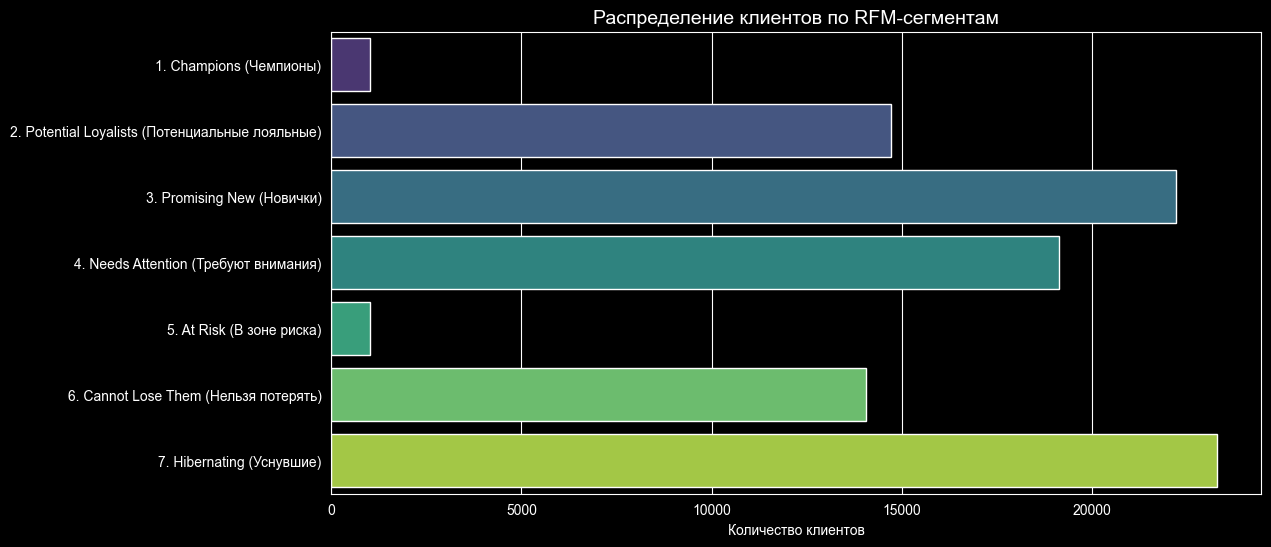

,Customer_Profile,customers_count,revenue_share
0,1. Champions (Чемпионы),1024,2.4
1,2. Potential Loyalists (Потенциальные лояльные),14718,28.2
2,3. Promising New (Новички),22212,10.2
3,4. Needs Attention (Требуют внимания),19119,18.9
4,5. At Risk (В зоне риска),1032,2.0
5,6. Cannot Lose Them (Нельзя потерять),14042,27.5
6,7. Hibernating (Уснувшие),23273,10.7


In [10]:
rfm_stats = customers.groupby('Customer_Profile').agg(
    customers_count=('customer_unique_id', 'count'),
    total_revenue=('total_spent', 'sum')
).reset_index().sort_values('Customer_Profile')

rfm_stats['revenue_share'] = (rfm_stats['total_revenue'] / rfm_stats['total_revenue'].sum() * 100).round(1)

plt.figure(figsize=(12, 6))
sns.barplot(data=rfm_stats, y='Customer_Profile', x='customers_count', palette='viridis')
plt.title('Распределение клиентов по RFM-сегментам', fontsize=14)
plt.xlabel('Количество клиентов')
plt.ylabel('')
plt.show()

display(rfm_stats[['Customer_Profile', 'customers_count', 'revenue_share']])